In [22]:
# jupyter notebook 전체화면으로 변경  
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [1]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pytorch_lightning as pl
import seaborn as sns

from my_funs import *
from sklearn import metrics
from matplotlib import gridspec
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'


/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [23]:
def confusion_matrix_plot(training, tft ,ewma_data, dong , title):
    fig = plt.figure(figsize=(25, 7))
    gs = gridspec.GridSpec(nrows=2, # row 몇 개 
                           ncols=2, # col 몇 개 
                           height_ratios=[1,1], 
                           width_ratios=[5,1]
                          )

    gs.update(wspace=0.025, hspace=0.2)
    ax0 = plt.subplot(gs[: , 0])
    ax1 = plt.subplot(gs[1,1])
    ax2 = plt.subplot(gs[0,1])

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.axis('off')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.axis('off')

    ax0.set_title(f'{dong}_plot' , fontsize = 20)
    ax2.set_title('confusion_matrix', fontsize = 20)
    ax1.set_title('recall & precision , MAE', fontsize = 20)

    predition5= np.array([])
    for i in range(1,59):
        val_data = get_val_dataloader(training ,ewma_data, 8760+24*i)
        pred , x, idx_df = tft.predict(val_data, mode='raw', return_x = True , return_index = True)
        dong_idx = idx_df[idx_df['h_dong'] == dong].index[0]
        predition5 = np.concatenate([predition5,pred['prediction'][dong_idx, : , 5]])

    ewma_dong_df = ewma_data[ewma_data['h_dong']==dong]
    ewma_df_index = ewma_dong_df[ewma_dong_df['time_idx'] > 8760-1]['REG_DTIME']
    ewma_org_count = ewma_dong_df[ewma_dong_df['time_idx'] > 8760-1]['count']

    org_df = data_processing('../../data/data.csv')
    dong_org_df = org_df[org_df['h_dong'] == dong]
    dong_org_count = dong_org_df[dong_org_df['time_idx'] > 8760-1]['count']

    dong_org_count = dong_org_count.to_numpy().round()
    dong_org_count = np.logical_not(dong_org_count < 1)
    predition5 = predition5.round()
    predition5 = np.logical_not(predition5 < 1)

    ax0.plot(ewma_df_index,dong_org_count , label = 'orginal target' , alpha=1)
    ax0.plot(ewma_df_index,predition5 ,label = '90% prediction round', alpha= 0.6, linestyle='--')
    ax0.legend()

    tn, fp, fn, tp = metrics.confusion_matrix(dong_org_count,predition5).ravel()

    c_mat = np.array([[tp , fp],[fn , tn]])
    ax1 = sns.heatmap(c_mat, annot=True, cbar = False, fmt='g',cmap='Blues')

    f1_score = metrics.f1_score(dong_org_count,predition5)
    recall = metrics.recall_score(dong_org_count,predition5)
    precision = metrics.precision_score(dong_org_count,predition5)
    MAE = abs(recall - precision)

    ax2.text(0.1, 3.1 , f'f1 score  {f1_score : 4f}' , fontsize=25)
    ax2.text(0.1, 3.4 , f'recall      {recall : 4f}' , fontsize=25)
    ax2.text(0.1, 3.7 , f'precision {precision : 4f}' , fontsize=25)
    ax2.text(0.1, 4.1 , f'MAE        {MAE : 4f}' , fontsize=25)

def f1_score_plot(training, tft ,ewma_data, title):
    f1_scores = []
    for dong in dongs[:5]:
        f1_score = confusion_matrix_plot(training, tft, ewma_data, dong ,title)
        f1_scores.append(f1_score)
    f1_score_mean = np.mean(f1_scores) 
    print(f'{title} f1 score  {f1_score_mean}')

In [24]:
dongs = sorted(['동산면', '후평1동', '사북면', '신북읍', '석사동', '남산면', '교  동', '신동면', '효자1동',
       '북산면', '서  면', '조운동', '동내면', '소양동', '강남동', '퇴계동', '근화동', '동  면',
       '신사우동', '약사명동', '남  면'])

In [25]:
data_sheet = pd.read_csv('../2022_11_02_TEST_ewma/result_ewma_lr_optim.csv')
#data_sheet = data_sheet[['ewma', 'model_ckpt']]
data_sheet['ewma'] = '../2022_11_02_TEST_ewma/' + data_sheet['ewma'] 
data_sheet['model_ckpt'] = '../2022_11_02_TEST_ewma/' + data_sheet['model_ckpt'] 
data_sheet

,Unnamed: 0,ewma,lr,optim,model_ckpt
0,0,../2022_11_02_TEST_ewma/alpha1/03.csv,0.100,Adam,../2022_11_02_TEST_ewma/all_test/lightning_log...
1,1,../2022_11_02_TEST_ewma/alpha1/03.csv,0.100,AdamW,../2022_11_02_TEST_ewma/all_test/lightning_log...
2,2,../2022_11_02_TEST_ewma/alpha1/03.csv,0.100,Adamax,../2022_11_02_TEST_ewma/all_test/lightning_log...
3,3,../2022_11_02_TEST_ewma/alpha1/03.csv,0.100,NAdam,../2022_11_02_TEST_ewma/all_test/lightning_log...
4,4,../2022_11_02_TEST_ewma/alpha1/03.csv,0.100,RAdam,../2022_11_02_TEST_ewma/all_test/lightning_log...
...,...,...,...,...,...
121,121,../2022_11_02_TEST_ewma/span1/5.csv,0.001,AdamW,../2022_11_02_TEST_ewma/all_test/lightning_log...
122,122,../2022_11_02_TEST_ewma/span1/5.csv,0.001,Adamax,../2022_11_02_TEST_ewma/all_test/lightning_log...
123,123,../2022_11_02_TEST_ewma/span1/5.csv,0.001,NAdam,../2022_11_02_TEST_ewma/all_test/lightning_log...
124,124,../2022_11_02_TEST_ewma/span1/5.csv,0.001,RAdam,../2022_11_02_TEST_ewma/all_test/lightning_log...


In [26]:
ewma_data = data_processing(data_sheet['ewma'].iloc[2])
training = get_training(ewma_data ,24 , 24*7)
tft = TemporalFusionTransformer.load_from_checkpoint(data_sheet['model_ckpt'].iloc[2])
pred , x, idx_df = tft.predict(ewma_data, mode='raw', return_x = True , return_index = True)

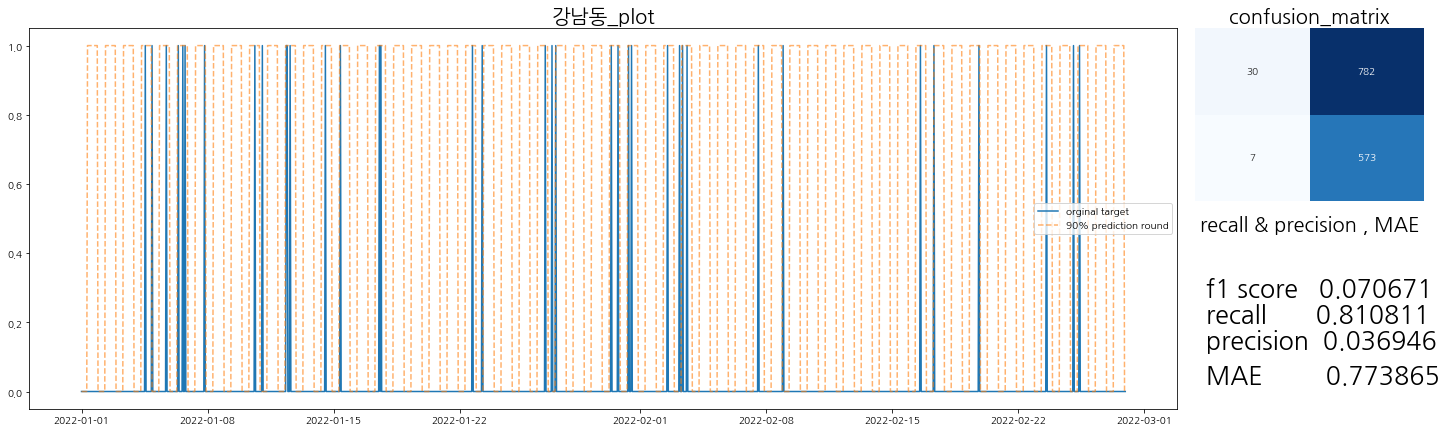

In [27]:
confusion_matrix_plot(training, tft, ewma_data, '강남동' ,'test')

강남동 f1_score 0.07067137809187281
교  동 f1_score 0.0


KeyboardInterrupt: 

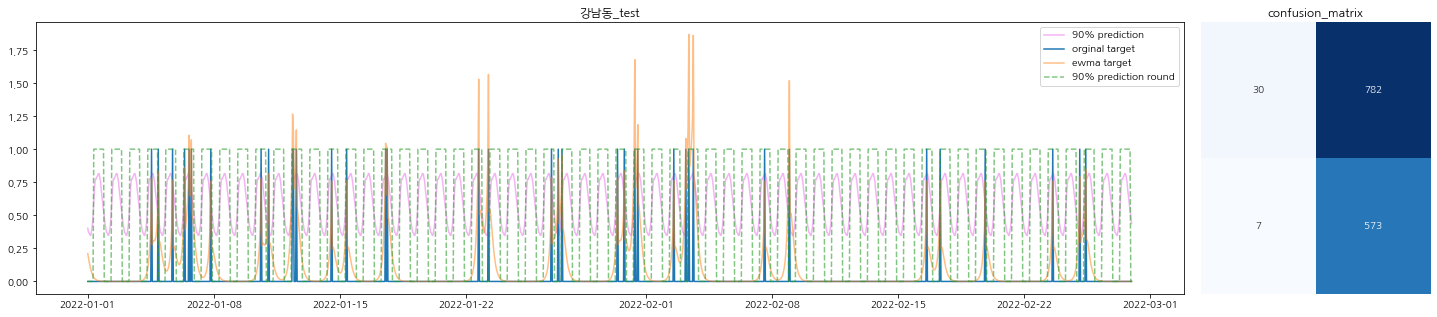

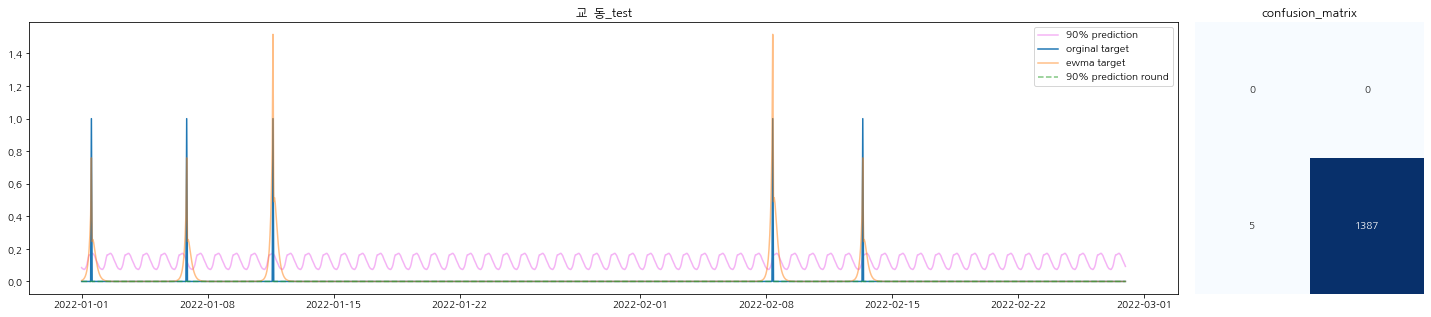

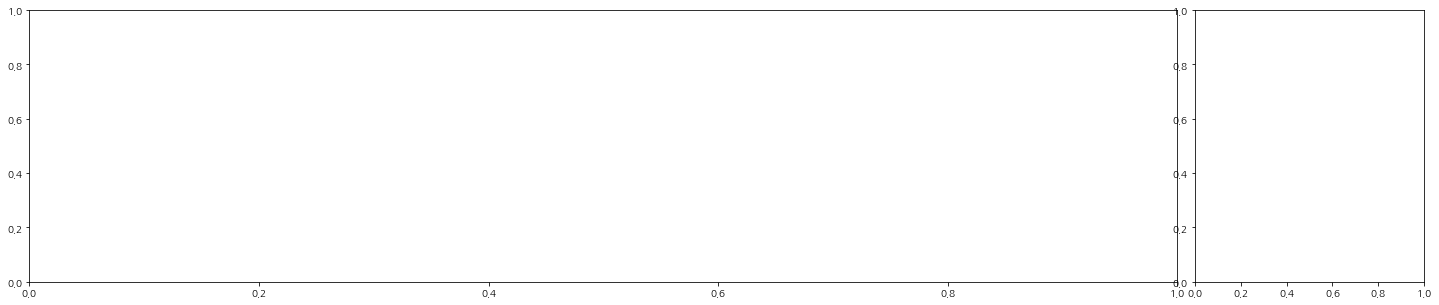

In [8]:
#confusion_matrix_plot(training, tft, ewma_data, '강남동' ,'test')
f1_score_plot(training, tft, ewma_data,'test')

# confusion matrix test


In [8]:
ewma_data = data_processing(data_sheet['ewma'].iloc[2])
training = get_training(ewma_data ,24 , 24*7)
tft = TemporalFusionTransformer.load_from_checkpoint(data_sheet['model_ckpt'].iloc[2])
pred , x, idx_df = tft.predict(ewma_data, mode='raw', return_x = True , return_index = True)

Text(0.1, 4.1, 'MAE         0.773865')

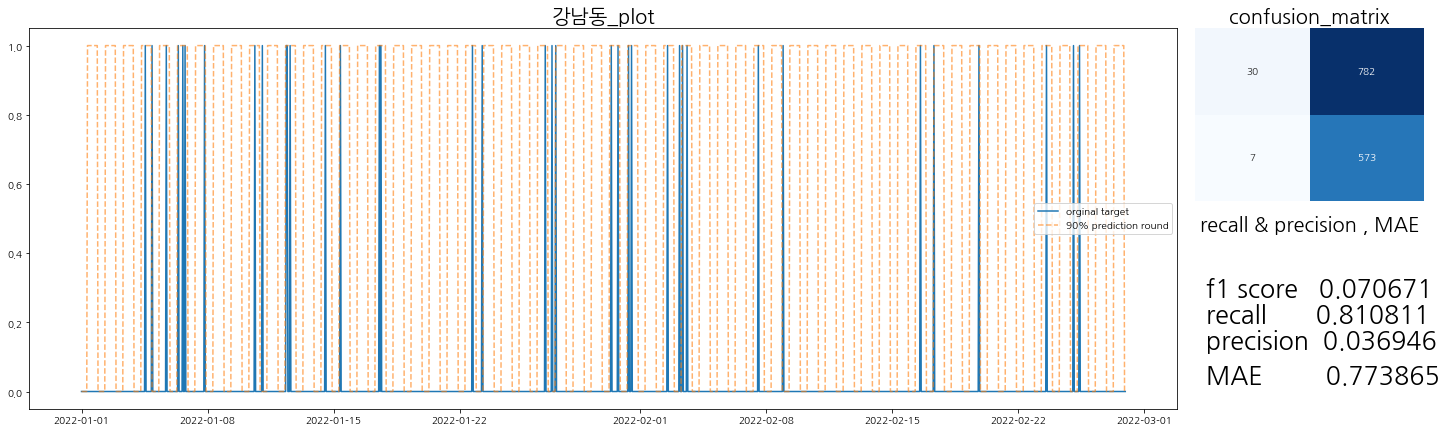

In [21]:
from matplotlib import gridspec
fig = plt.figure(figsize=(25, 7))
gs = gridspec.GridSpec(nrows=2, # row 몇 개 
                       ncols=2, # col 몇 개 
                       height_ratios=[1,1], 
                       width_ratios=[5,1]
                      )

gs.update(wspace=0.025, hspace=0.2)
ax0 = plt.subplot(gs[: , 0])
ax1 = plt.subplot(gs[1,1])
ax2 = plt.subplot(gs[0,1])

ax1.set_xticks([])
ax1.set_yticks([])
ax1.axis('off')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.axis('off')

ax0.set_title(f'{dong}_plot' , fontsize = 20)
ax2.set_title('confusion_matrix', fontsize = 20)
ax1.set_title('recall & precision , MAE', fontsize = 20)

predition5= np.array([])
for i in range(1,59):
    val_data = get_val_dataloader(training ,ewma_data, 8760+24*i)
    pred , x, idx_df = tft.predict(val_data, mode='raw', return_x = True , return_index = True)
    dong_idx = idx_df[idx_df['h_dong'] == dong].index[0]
    predition5 = np.concatenate([predition5,pred['prediction'][dong_idx, : , 5]])
        
ewma_dong_df = ewma_data[ewma_data['h_dong']==dong]
ewma_df_index = ewma_dong_df[ewma_dong_df['time_idx'] > 8760-1]['REG_DTIME']
ewma_org_count = ewma_dong_df[ewma_dong_df['time_idx'] > 8760-1]['count']

org_df = data_processing('../../data/data.csv')
dong_org_df = org_df[org_df['h_dong'] == dong]
dong_org_count = dong_org_df[dong_org_df['time_idx'] > 8760-1]['count']

dong_org_count = dong_org_count.to_numpy().round()
dong_org_count = np.logical_not(dong_org_count < 1)
predition5 = predition5.round()
predition5 = np.logical_not(predition5 < 1)

ax0.plot(ewma_df_index,dong_org_count , label = 'orginal target' , alpha=1)
ax0.plot(ewma_df_index,predition5 ,label = '90% prediction round', alpha= 0.6, linestyle='--')
ax0.legend()

tn, fp, fn, tp = metrics.confusion_matrix(dong_org_count,predition5).ravel()

c_mat = np.array([[tp , fp],[fn , tn]])
ax1 = sns.heatmap(c_mat, annot=True, cbar = False, fmt='g',cmap='Blues')

f1_score = metrics.f1_score(dong_org_count,predition5)
recall = metrics.recall_score(dong_org_count,predition5)
precision = metrics.precision_score(dong_org_count,predition5)
MAE = abs(recall - precision)

ax2.text(0.1, 3.1 , f'f1 score  {f1_score : 4f}' , fontsize=25)
ax2.text(0.1, 3.4 , f'recall      {recall : 4f}' , fontsize=25)
ax2.text(0.1, 3.7 , f'precision {precision : 4f}' , fontsize=25)
ax2.text(0.1, 4.1 , f'MAE        {MAE : 4f}' , fontsize=25)

Text(0.5, 1.0, 'recall & precision , MAE')

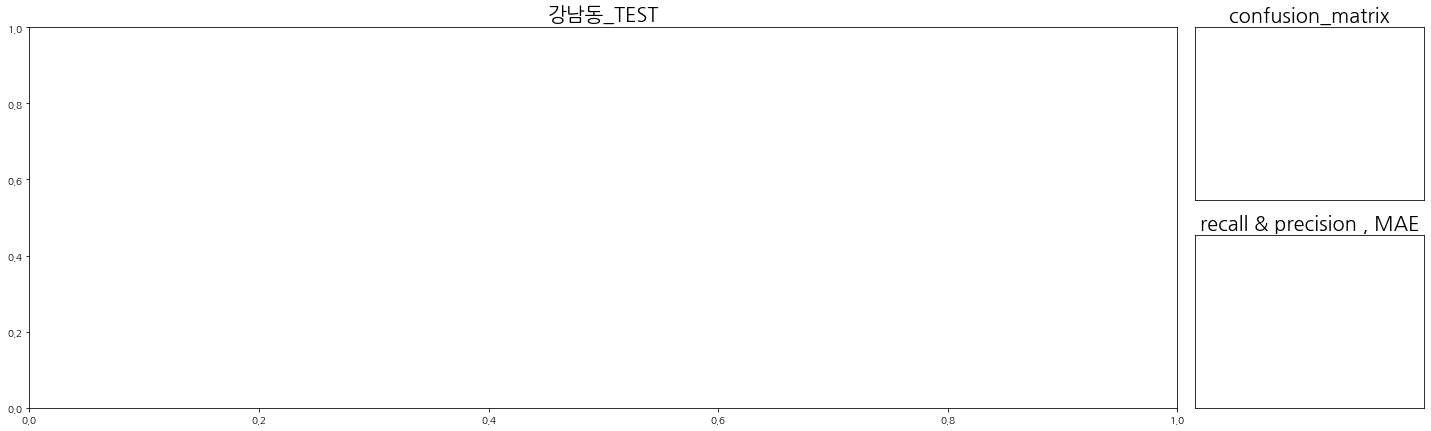

In [20]:
from matplotlib import gridspec
fig = plt.figure(figsize=(25, 7))
gs = gridspec.GridSpec(nrows=2, # row 몇 개 
                       ncols=2, # col 몇 개 
                       height_ratios=[1,1], 
                       width_ratios=[5,1]
                      )

gs.update(wspace=0.025, hspace=0.2)
ax0 = plt.subplot(gs[: , 0])
ax1 = plt.subplot(gs[1,1])
ax2 = plt.subplot(gs[0,1])

ax2.set_xticks([])
ax2.set_yticks([])


ax1.set_xticks([])
ax1.set_yticks([])

ax0.set_title(f'{dong}_TEST' , fontsize = 20)
ax2.set_title('confusion_matrix', fontsize = 20)
ax1.set_title('recall & precision , MAE', fontsize = 20)


